![Add a relevant banner image here](path_to_image)

# Analyzing Traffic Accident Severity in the U.S.
#### (Using US Accidents dataset 2016-2023)

## 1. Overview  
  
This project analyzes U.S. traffic accident data to identify factors influencing accident severity. The study focuses on the correlation between road condition, time, and infrastructure to mitigate large-scale traffic disruptions.

## 2. Business Understanding

The primary goal is to determine the variables that lead to high-severity accidents (Level 3 and 4) which cause significant road closure. Analysis focuses on temporal, infrastructural, and environmental data points to improve traffic management efficiency.

**Key Deliverables**  
- Risk Identification
- Infrastructure Assessment
- Operational Optimization
- Economic Impact Reduction

**Methodology**  
- Phase 1 (Sample-based Exploration)
- Phase 2 (Full-scale Modeling)

## [Phase 1] Exploratory Analysis (Sample-base)  

## 3. Data Understanding (Initial Inspection & Sampling)

This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. 

### 3.1 Data Loading & Schema Verification Strategy  
The dataset is examined to verify integrity and identify patterns across severity levels. Statistical profiling is used to find factors that distinguish minor incidents from major accidents.

In [34]:
import pandas as pd
import numpy as np
import sys

In [37]:
# File path
file_path = "Data/US_Accidents_March23.csv"

In [45]:
# Preliminary Analysis (Dataset is over 3GB)
preview_size = 10000
df_check = pd.read_csv(file_path, nrows=preview_size)

print(f"== Schema Discovery (first {preview_size} rows) ==")
for col in df_check.columns:
    unique_count = df_check[col].nunique()
    total_count = len(df_check[col])
    dtype = df_check[col].dtype

    # If unique values are less than 5% of total rows, it's a candidate for 'category'
    is_candidate = "Candidate for Category" if (unique_count / total_count) < 0.05 else ""
    print(f"Column: {col:<25} | Dtype: {str(dtype):<15} | Unique: {unique_count:<6} {is_candidate}")

== Schema Discovery (first 10000 rows) ==
Column: ID                        | Dtype: object          | Unique: 10000  
Column: Source                    | Dtype: object          | Unique: 2      Candidate for Category
Column: Severity                  | Dtype: int64           | Unique: 4      Candidate for Category
Column: Start_Time                | Dtype: object          | Unique: 9907   
Column: End_Time                  | Dtype: object          | Unique: 9921   
Column: Start_Lat                 | Dtype: float64         | Unique: 6372   
Column: Start_Lng                 | Dtype: float64         | Unique: 6277   
Column: End_Lat                   | Dtype: float64         | Unique: 0      Candidate for Category
Column: End_Lng                   | Dtype: float64         | Unique: 0      Candidate for Category
Column: Distance(mi)              | Dtype: float64         | Unique: 45     Candidate for Category
Column: Description               | Dtype: object          | Unique: 8528   
C

In [55]:
# Memory-Safe Chunked Sampling
'''Chunks allows to monitor the process and handle potential 'Mixed Type' warnings'''
chunk_size = 100000
sample_list = []
total_rows_processed = 0
sample_rate = 0.10

print("=== Starting Chunk-based Sampling ===")

try: 
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        sampled_chunk = chunk.sample(frac=sample_rate, random_state=42)
        sample_list.append(sampled_chunk)
        total_rows_processed += len(chunk)

        if total_rows_processed % 1000000 == 0:
            print(f"Processed {total_rows_processed} rows...")

        df = pd.concat(sample_list, axis=0)
        print(f"\nSampling Complete. Total Rows Sampled: {len(df)}")

except Exception as e:
    print(f"Error during processing: {e}")

=== Starting Chunk-based Sampling ===

Sampling Complete. Total Rows Sampled: 10000

Sampling Complete. Total Rows Sampled: 20000

Sampling Complete. Total Rows Sampled: 30000

Sampling Complete. Total Rows Sampled: 40000

Sampling Complete. Total Rows Sampled: 50000

Sampling Complete. Total Rows Sampled: 60000

Sampling Complete. Total Rows Sampled: 70000

Sampling Complete. Total Rows Sampled: 80000

Sampling Complete. Total Rows Sampled: 90000
Processed 1000000 rows...

Sampling Complete. Total Rows Sampled: 100000

Sampling Complete. Total Rows Sampled: 110000

Sampling Complete. Total Rows Sampled: 120000

Sampling Complete. Total Rows Sampled: 130000

Sampling Complete. Total Rows Sampled: 140000

Sampling Complete. Total Rows Sampled: 150000

Sampling Complete. Total Rows Sampled: 160000

Sampling Complete. Total Rows Sampled: 170000

Sampling Complete. Total Rows Sampled: 180000

Sampling Complete. Total Rows Sampled: 190000
Processed 2000000 rows...

Sampling Complete. Total 

In [59]:
# Summary of Column Health
'''Identify which columns are relaible and which need significant cleaning.'''
health_report = pd.DataFrame({'Dtype': df.dtypes,
                              'Null_Count': df.isnull().sum(),
                              'Null_Percentage': (df.isnull().sum() / len(df)) * 100,
                              'Unique_Values': df.nunique()})

# Sort
print("=== Column Health Report (Top 20) ===")
print(health_report.sort_values(by='Null_Percentage', ascending=False).head(20))

# Overall completeness
total_cells = np.prod(df.shape)
total_nulls = df.isnull().sum().sum()
print(f"\n=== Overall Data Quality Summary ===")
print(f"Total Rows: {len(df)}")
print(f"Total Missing Values: {total_nulls} ({ (total_nulls/total_cells)*100:.2f}% of total data)")
print(f"Columns with > 50% Missing: {len(health_report[health_report['Null_Percentage'] > 50])}")

=== Column Health Report (Top 20) ===
                         Dtype  Null_Count  Null_Percentage  Unique_Values
End_Lat                float64      340298        44.032198         316661
End_Lng                float64      340298        44.032198         318839
Precipitation(in)      float64      221061        28.603758            187
Wind_Chill(F)          float64      200187        25.902808            835
Wind_Speed(mph)        float64       57526         7.443465            112
Visibility(mi)         float64       17950         2.322605             61
Wind_Direction          object       17819         2.305655             24
Humidity(%)            float64       17588         2.275765            100
Weather_Condition       object       17550         2.270848            117
Temperature(F)         float64       16559         2.142620            752
Pressure(in)           float64       14314         1.852132           1022
Weather_Timestamp       object       12212         1.580148   

### 3.2 Numerical & Target Distribution

In [62]:
# Numerical Feature Distribution & Outliers
'''Weather and physical impact metrics.'''
print("=== Detailed Statistics for Key Numerical Columns ===")
key_num_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Checking percentiles
stats = df[key_num_cols].describe(percentiles=[.01, .25, .5, .75, .99])
print(stats)

=== Detailed Statistics for Key Numerical Columns ===
            Severity   Distance(mi)  Temperature(F)  Visibility(mi)  \
count  772839.000000  772839.000000   756280.000000   754889.000000   
mean        2.212731       0.560512       61.683076        9.093305   
std         0.488106       1.737856       18.985987        2.690374   
min         1.000000       0.000000      -89.000000        0.000000   
1%          2.000000       0.000000       12.900000        0.500000   
25%         2.000000       0.000000       49.000000       10.000000   
50%         2.000000       0.030000       64.000000       10.000000   
75%         2.000000       0.465000       76.000000       10.000000   
99%         4.000000       6.910000       96.000000       10.000000   
max         4.000000     149.690000      196.000000      100.000000   

       Wind_Speed(mph)  Precipitation(in)  
count    715313.000000      551778.000000  
mean          7.685036           0.008221  
std           5.576693          

In [64]:
# Target Variable (Severity)
print("=== Severity Distribution (Target Variable) ===")
severity_counts = df['Severity'].value_counts().sort_index()
severity_pct = df['Severity'].value_counts(normalize=True).sort_index() *100

severity_report = pd.DataFrame({'Count': severity_counts,
                                'Percentage (%)': severity_pct})
print(severity_report)

=== Severity Distribution (Target Variable) ===
           Count  Percentage (%)
Severity                        
1           6757        0.874309
2         615508       79.642461
3         129984       16.819027
4          20590        2.664203


In [66]:
# Categorical Dominance (Top values)
print("=== Top 5 States and Weather Conditions ===")
print("Top States:\n", df['State'].value_counts().head(5))
print("\nTop Weather Conditions:\n", df['Weather_Condition'].value_counts().head(5))

=== Top 5 States and Weather Conditions ===
Top States:
 State
CA    174744
FL     87871
TX     58147
SC     38409
NY     34747
Name: count, dtype: int64

Top Weather Conditions:
 Weather_Condition
Fair             256560
Mostly Cloudy    101261
Cloudy            81702
Clear             81006
Partly Cloudy     69687
Name: count, dtype: int64


### 3.3 Severity-Segmented Analysis

In [73]:
# Comparison of Numerical Features by Severity
print("=== Average Values by Severity Level ===")
'''Logical influences'''
comparison_cols = ['Distance(mi)', 'Temperature(F)', 'Visibility(mi)', 'Precipitation(in)']
severity_group_num = df.groupby('Severity')[comparison_cols].mean()
print(severity_group_num)

=== Average Values by Severity Level ===
          Distance(mi)  Temperature(F)  Visibility(mi)  Precipitation(in)
Severity                                                                 
1             0.106166       72.264162        9.469130           0.004633
2             0.561549       61.586507        9.086852           0.006987
3             0.423562       62.151764        9.106537           0.017194
4             1.543170       58.082681        9.078400           0.008855


In [77]:
# Road Feature Impact (POI) by Severity
poi_cols = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']
print("=== Road Feature Frequency by Severity (%) ===")
severity_group_poi = df.groupby('Severity')[poi_cols].mean() * 100
print(severity_group_poi)

=== Road Feature Frequency by Severity (%) ===
           Junction  Traffic_Signal   Crossing      Stop   Station   Railway
Severity                                                                    
1          4.632233       38.656208  27.408613  3.611070  3.729466  1.524345
2          6.784640       16.332038  12.848086  3.201096  2.998174  0.896333
3         10.303576        6.787758   3.679684  0.560838  0.950117  0.687008
4         10.029140        9.912579   6.464303  2.778048  1.306459  0.830500


## 4. Data Preparation (Sample)
Data is cleaned by removing outliers and adding time variables. This process ensures each severity level is represented accurately by filtering out errors.

### 4.1 Physical Outlier Cleaning

In [86]:
# By US meteorological limits and logical thresholds
print("=== Cleaning Outliers ===")
initial_len = len(df)
df = df[(df['Wind_Speed(mph)'] <= 150) &
        (df['Temperature(F)'] >= -50) &
        (df['Temperature(F)'] <= 130) &
        (df['Visibility(mi)'] <=50)]
print(f"Removed {initial_len - len(df)} rows containing phyiscal outliers.")

=== Cleaning Outliers ===
Removed 62360 rows containing phyiscal outliers.


### 4.2 DateTime Convert

In [95]:
# Convert string to datetime and extracting features for periodic analysis
df = df.copy()

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday # 0=Monday, 6=Sunday
df['Month'] = df['Start_Time'].dt.month

### 4.3 Missing Values

In [98]:
# Precipiation NaN is highly likely to be 0 (no rain recorded)
df['Precipiation(in)'] = df['Precipitation(in)'].fillna(0)

In [101]:
# Categorical weather, fill 'unknown' instead of dropping
'''Maintain the sample size for Severity 4'''
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

### 4.4 Drop Redundant Columns (Unique value = 1)

In [106]:
cols_to_drop = ['Country', 'Turning_Loop']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

### 4.5 Preview after data preparation  
Final data dimension and memory efficiency are verified to ensure the dataset is optimized for analysis. The preview of time-based variables confirms that features for hourly, weekly, and monthly are correctly extracted.

In [117]:
# Final check
print(f"=== Final cleaned dataset size: {df.shape}")
print(f"Remaining memory usage: {df.memory_usage().sum() / (1024**2):.2f} MB")

# Preview the features
print("\n=== Sample of Features ===")
print(df[['Severity', 'Hour', 'Weekday', 'Month']].head(20))

=== Final cleaned dataset size: (638857, 48)
Remaining memory usage: 180.34 MB

=== Sample of Features ===
       Severity  Hour  Weekday  Month
80184         3    12        2      9
19864         3    20        1      9
92991         3    17        5      8
84004         3    16        4     10
80917         3    14        5     10
50074         3    13        2      7
27701         3    23        2      8
42141         3     5        0      6
45080         3    18        1      6
20424         2     1        4      9
88702         2    18        3      8
149           2     7        0      2
63120         2    17        0      1
64883         3    12        0      1
2495          2    11        4      7
80296         3    20        2      9
19447         2    12        2     11
41331         3    12        0      6
88636         2    15        3      8
94892         3    20        4      9


## 5. Analysis (Sample-based EDA)

Definition of Severity: Accident severity is measured by its impact of traffic flow on a scale of 1 to 4
- Severity 1: Minor impact on traffic with minimal delays
- Severity 2: Partial lane closure with moderate delays
- Severity 3: Significant lane blockage causing extensive traffic congestion
- Severity 4: Complete road closure or major incident leading to severe traffic distuption

Data Source: Unified traffic data form the U.S. Department of Transporation (DOT) and National Weather Service (NWS)

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

### 5.1 Hourly Distribution by Severity

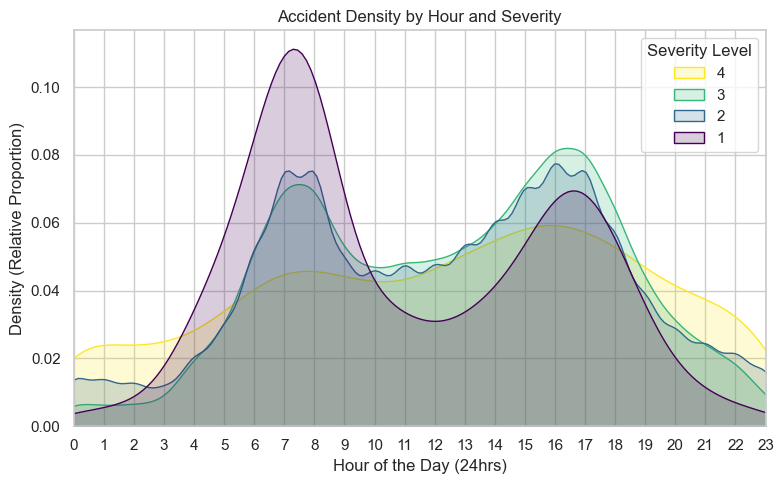

In [126]:
plt.figure(figsize=(8,5))
sns.set_theme(style='whitegrid')

# Compare hourly density
sns.kdeplot(data=df, x='Hour', hue='Severity', palette='viridis',
            common_norm=False, fill=True, alpha=0.2, bw_adjust=1.2)

plt.title('Accident Density by Hour and Severity')
plt.xlabel('Hour of the Day (24hrs)')
plt.ylabel('Density (Relative Proportion)')
plt.xticks(range(0, 24))
plt.xlim(0, 23)

plt.legend(title='Severity Level', labels=['4', '3', '2', '1'])
plt.tight_layout()
plt.show()

In [130]:
# Table
def get_time_period(hour):
    if 0 <= hour < 6: return 'Late Night (00-06)'
    elif 6 <= hour < 10: return 'Morning Rush (06-10)'
    elif 10 <= hour < 16: return 'Mid-Day (10-16)'
    elif 16 <= hour < 20: return 'Evening Rush (16-20)'
    else: return 'Night (20-24)'

df['Time_Period'] = df['Hour'].apply(get_time_period)
severity_time_table = pd.crosstab(df['Time_Period'], df['Severity'], normalize='columns') * 100
print('=== Percentage Distribution of Accidents by Time Period ===')
print(severity_time_table)

=== Percentage Distribution of Accidents by Time Period ===
Severity                      1          2          3          4
Time_Period                                                     
Evening Rush (16-20)  24.710895  24.449276  27.294718  22.046859
Late Night (00-06)    11.031649  10.059800   7.383939  16.321037
Mid-Day (10-16)       21.545953  31.697417  32.366629  29.357069
Morning Rush (06-10)  39.196592  24.845219  24.737290  17.972717
Night (20-24)          3.514912   8.948288   8.217425  14.302318


**Comment**  
Severity 4 accidents show a distinct trend, with significantly higher proportions during Night and Late Night hours (20:00-06:00) compared to other levels. In contrast, Severity 1 incidents are heavily concentrated during the Morning Rush, suggsting that lower speeds during peak hours may limit accident severity despite higher frequency.

### 5.2 Road Features (POI)

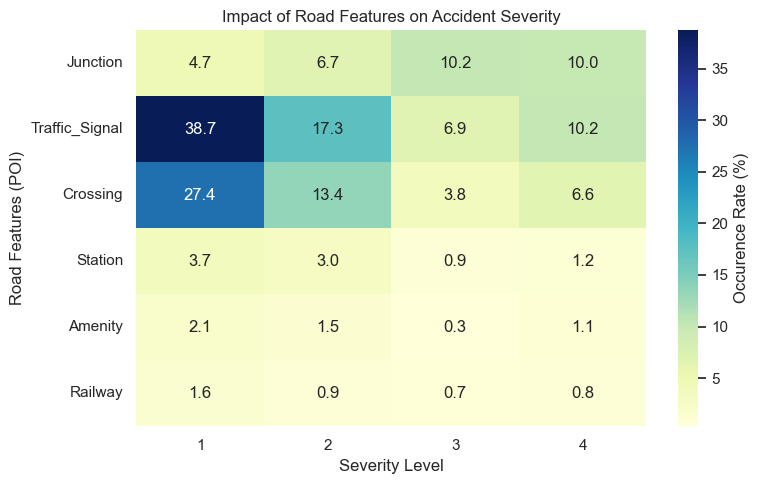

=== Road Feature Occurence Rate (%) by Severity ===
Severity            1      2      3      4
Junction         4.67   6.75  10.19   9.97
Traffic_Signal  38.71  17.31   6.92  10.17
Crossing        27.45  13.42   3.77   6.63
Station          3.67   3.05   0.93   1.22
Amenity          2.07   1.47   0.34   1.08
Railway          1.55   0.91   0.66   0.81


In [143]:
# Key inftrastucture features
poi_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Station', 'Amenity', 'Railway']

# Calculate the percentage of 'True' values for each feature per Severity level
poi_analysis = df.groupby('Severity')[poi_features].mean() * 100

# Visualize
plt.figure(figsize=(8,5))
sns.heatmap(poi_analysis.T, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Occurence Rate (%)'})

plt.title('Impact of Road Features on Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Road Features (POI)')
plt.tight_layout()
plt.show()

# Table
print("=== Road Feature Occurence Rate (%) by Severity ===")
print(poi_analysis.T.round(2))

**Comment**  
Traffic Signals and Crossings are hotspots for Severity 1, whereas Junctions are critical triggers for Severity 3 and 4. This indicates that while urban stops cause frequent small accidents, high-speed merging points are the primary cause of total traffic paralysis.

### 5.3 Weather & Environmental Analysis

In [149]:
# Key weather metrics
weather_metrics = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipiation(in)']
weather_analysis = df.groupby('Severity')[weather_metrics].mean()

print("=== Average Weather Metrics ===")
print(weather_analysis.round(2))

=== Average Weather Metrics ===
          Temperature(F)  Humidity(%)  Visibility(mi)  Precipiation(in)
Severity                                                               
1                  72.28        62.62            9.46              0.00
2                  61.75        64.47            9.10              0.01
3                  62.51        64.72            9.11              0.01
4                  58.46        66.44            9.10              0.01


**Comment**  
Severity 4 incidents correlate with lower temperatures and higher humidity, often reflecting hazardous night-time or damp conditions. Coversely, Severity 1 accidents peak with in warmer, drier weather, typical of daylight commuting hours.

### 5.4 Spatial Analysis (Top 10 States)

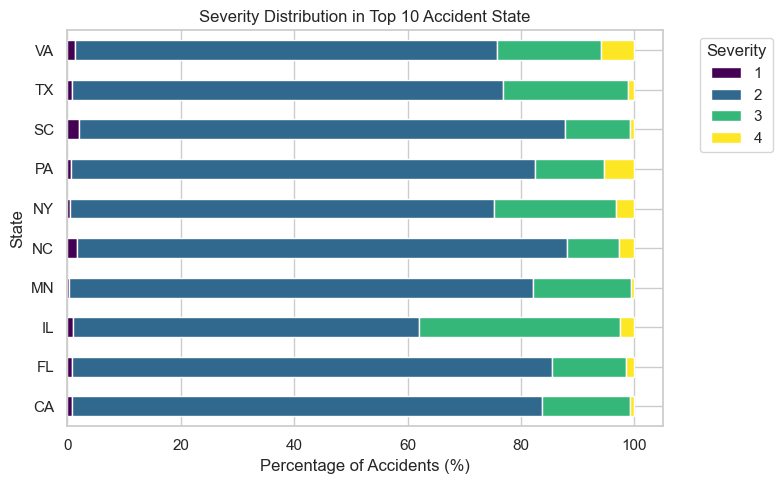

Severity     1      2      3     4
State                             
CA        0.74  82.90  15.64  0.71
FL        0.87  84.56  13.03  1.54
IL        1.00  60.95  35.44  2.61
MN        0.36  81.70  17.41  0.53
NC        1.75  86.34   9.27  2.64
NY        0.41  74.78  21.61  3.20
PA        0.67  81.82  12.07  5.45
SC        2.01  85.82  11.40  0.76
TX        0.84  76.01  21.96  1.19
VA        1.38  74.36  18.28  5.98


In [161]:
# Top 10 states
top_10_states = df['State'].value_counts().nlargest(10).index
df_top_states = df[df['State'].isin(top_10_states)]

# Cross-tabulation: State and Severity
state_severity = pd.crosstab(df_top_states['State'], df_top_states['Severity'], normalize='index') * 100

# Visualzie
state_severity.plot(kind='barh', stacked=True, figsize=(8,5), colormap='viridis')
plt.title('Severity Distribution in Top 10 Accident State')
plt.xlabel('Percentage of Accidents (%)')
plt.ylabel('State')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Table
print(state_severity.round(2))

**Comment**  
Spatial analysis reveals that while CA and FL have the highest accident frequency, they are dominated by low_severity incidents. In contrast, VA and PA exhibit a significaltly higer risk of Severity 4, indicating that regional infrastructure or environmental factors in these states lead to more catastrophic traffic disruptions.

### 5.5 Integrated Insight Dashboard (Final Summary)

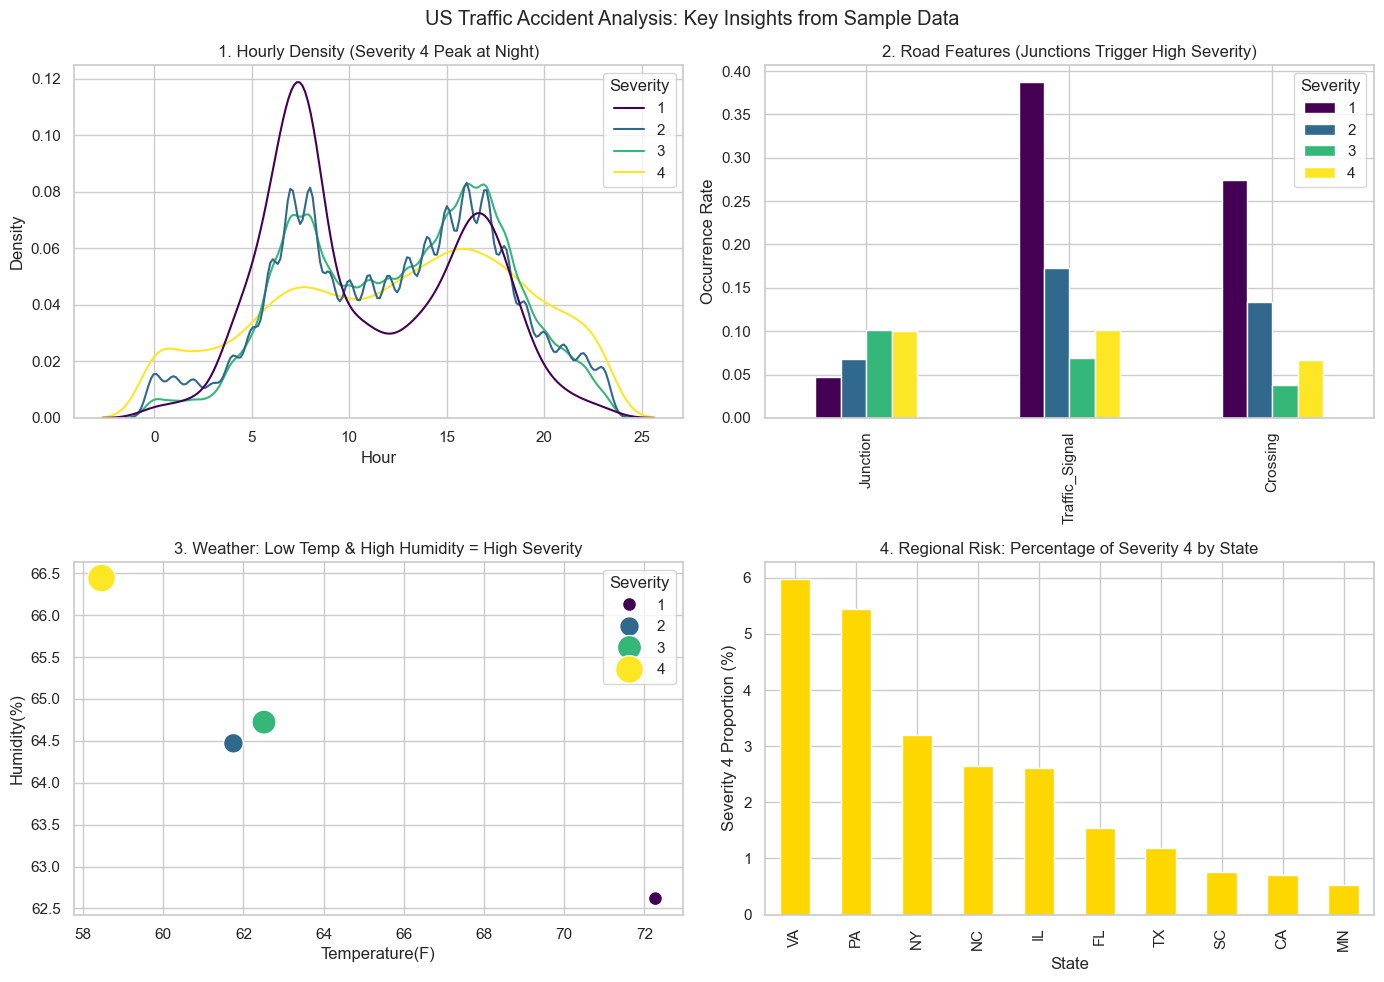

In [178]:
# Set the visualization layout
fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Temporal: Severity 4 vs Others (Density)
sns.kdeplot(data=df, x='Hour', hue='Severity', common_norm=False, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('1. Hourly Density (Severity 4 Peak at Night)')

# Infrastructure: Top Critical Features (Junction & Signal)
poi_summary = df.groupby('Severity')[['Junction', 'Traffic_Signal', 'Crossing']].mean().T
poi_summary.plot(kind='bar', ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('2. Road Features (Junctions Trigger High Severity)')
axes[0,1].set_ylabel('Occurrence Rate')

# Environmental: Temperature & Humidity Trend
sns.scatterplot(data=weather_analysis, x='Temperature(F)', y='Humidity(%)', 
                hue='Severity', size='Severity', sizes=(100, 400), palette='viridis', ax=axes[1,0])
axes[1,0].set_title('3. Weather: Low Temp & High Humidity = High Severity')

# Spatial: Severity 4 Risk by State
state_severity[4].sort_values(ascending=False).plot(kind='bar', color='gold', ax=axes[1,1])
axes[1,1].set_title('4. Regional Risk: Percentage of Severity 4 by State')
axes[1,1].set_ylabel('Severity 4 Proportion (%)')

plt.suptitle('US Traffic Accident Analysis: Key Insights from Sample Data')
plt.tight_layout()
plt.show()

## [Phase 2] Full-scale Modeling (Enire Dataset)

## 6. Evaluation

### 6.1 Business Insight/Recommendation 1

### 6.2 Business Insight/Recommendation 2

### 6.3 Business Insight/Recommendation 3

### 6.4 Tableau Dashboard link

## 7. Conclusion and Next Steps
Text here